In [1]:
from pathlib import Path
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.patches as mpatches
from itertools import cycle

In [38]:
#subject_dir = Path(r"/home/charlotte/Documents/Tesi/Motoneuron_Synergies_Driven_Gesture_Prediction/glove_sample_subj_01_trial_01")
subject_dir = Path(r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_sample_subj_01_trial_06")
# Record WFDB: .hea (header) and .dat (dati).
hea_files = sorted(subject_dir.glob("*.hea"))
print("File .hea trovati:")
for f in hea_files:
    print(f.name)

# Choose the first .hea file (assuming there's only one record per trial)
record_base = hea_files[0].with_suffix("")  

# Read record: wfdb load automatically the .dat file
rec = wfdb.rdrecord(str(record_base))

print("\nName Angles Glove:")
for i, name in enumerate(rec.sig_name):
    print(i, name)

data = rec.p_signal
print("\nShape dati:", data.shape)
print("Sampling Frequency (I think here there is an error in the file, paper explicitly says 200 Hz):", rec.fs)

File .hea trovati:
hdkw_kin_exp03_subj01_6_glove.hea

Name Angles Glove:
0 TN
1 TF
2 T&I
3 IN
4 IF
5 I&M
6 MN
7 MF
8 M&R
9 RN
10 RF
11 R&P
12 PN
13 PF

Shape dati: (37400, 14)
Sampling Frequency (I think here there is an error in the file, paper explicitly says 200 Hz): 2000


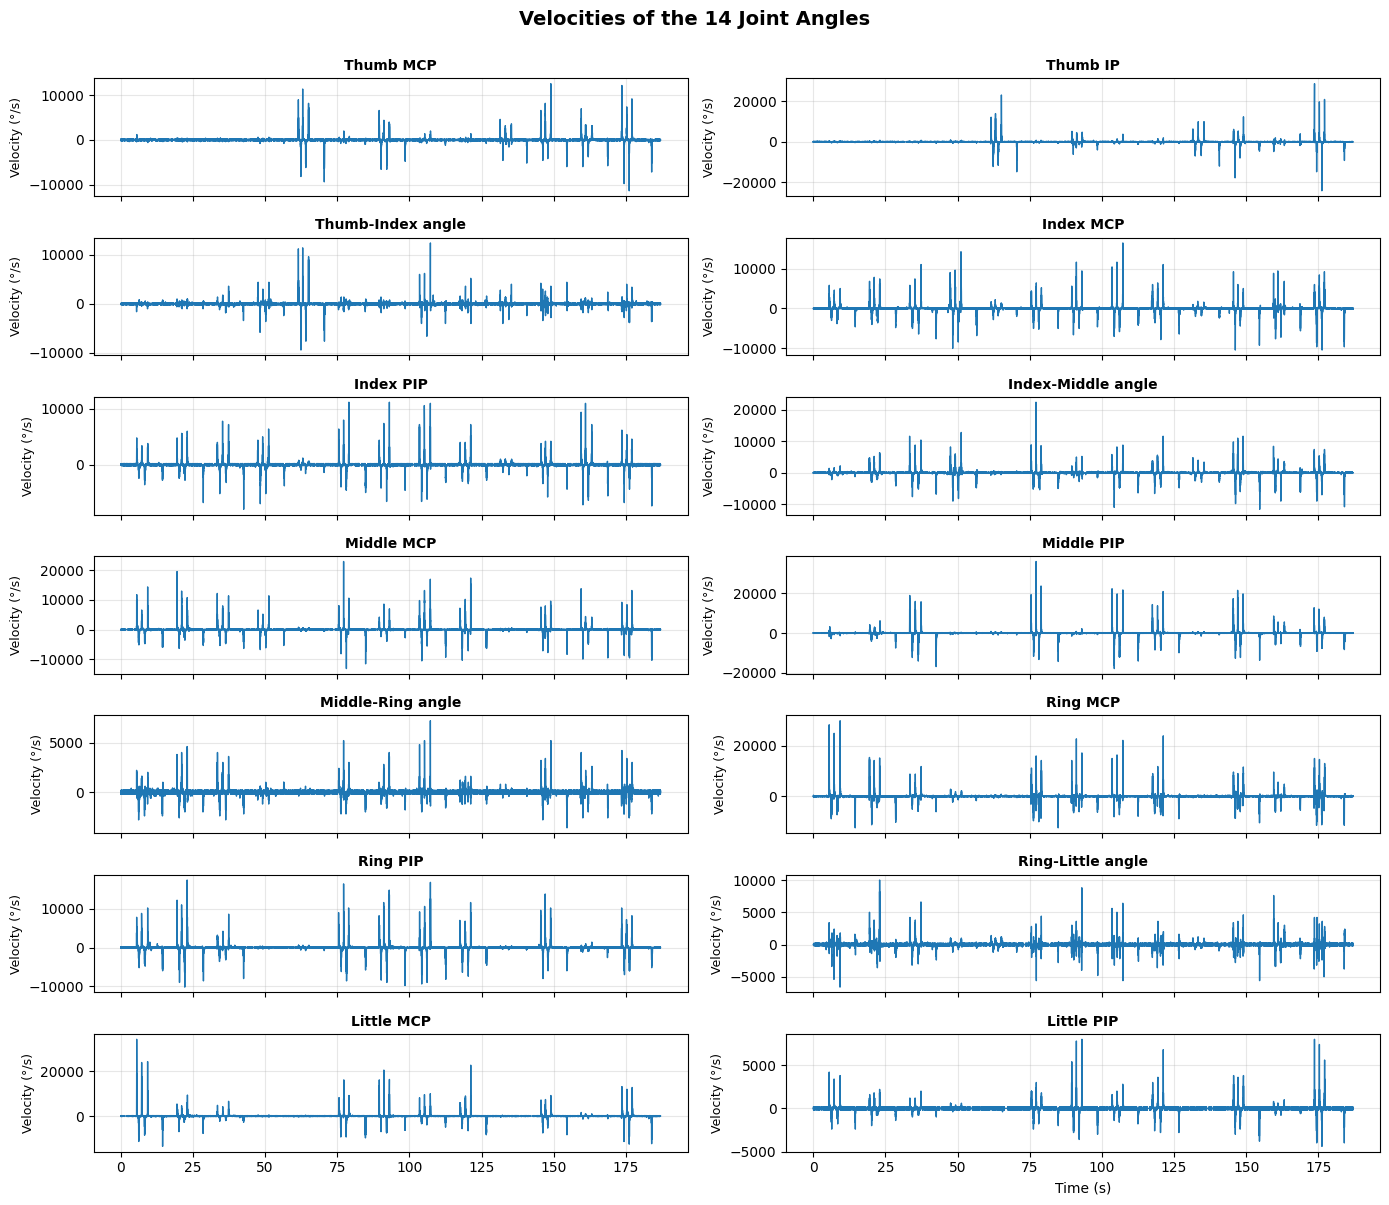

Total duration: 186.99 seconds
Number of velocity samples: 37399


In [39]:
# Compute velocities (derivative of the signal values of these channels for finger flexion and abduction).
# These are not angles, so velocity is in signal units/s, not degrees/s.

fs = 200  
dt = 1 / fs
velocities = np.diff(data, axis=0) / dt

time = np.arange(velocities.shape[0]) / fs

# Channel Mapping
channel_names = [
    "Thumb MCP", "Thumb IP", "Thumb-Index angle",
    "Index MCP", "Index PIP", "Index-Middle angle",
    "Middle MCP", "Middle PIP", "Middle-Ring angle",
    "Ring MCP", "Ring PIP", "Ring-Little angle",
    "Little MCP", "Little PIP"
]

# Plot: Signal gloves angles velocities for all 14 channels.
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ch in range(14):
    axes[ch].plot(time, velocities[:, ch], linewidth=1)
    axes[ch].set_title(channel_names[ch], fontsize=10, fontweight='bold')
    axes[ch].set_ylabel('Velocity (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.suptitle('Velocities of the 14 Joint Angles', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"Total duration: {time[-1]:.2f} seconds")
print(f"Number of velocity samples: {velocities.shape[0]}")

## Define the Rig in Unity in order to choose wheter preprocessing the angular information

In [40]:
df = pd.DataFrame(data, columns=channel_names)
df.to_csv("glove_data.csv", index=False)

In [41]:
record_base = r"C:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\glove_sample_subj_01_trial_06"   # without .hea/.dat

channel_names = [
    "Thumb_MCP", "Thumb_IP", "Thumb_Index_abd",
    "Index_MCP", "Index_PIP", "Index_Middle_abd",
    "Middle_MCP", "Middle_PIP", "Middle_Ring_abd",
    "Ring_MCP", "Ring_PIP", "Ring_Little_abd",
    "Little_MCP", "Little_PIP"
]

# Practical mapping of normalized signal values to degrees for Unity.
flexion_channels = {
    "Thumb_MCP": 60.0,
    "Thumb_IP": 80.0,
    "Index_MCP": 75.0,
    "Index_PIP": 95.0,
    "Middle_MCP": 75.0,
    "Middle_PIP": 100.0,
    "Ring_MCP": 75.0,
    "Ring_PIP": 100.0,
    "Little_MCP": 75.0,
    "Little_PIP": 95.0,
}

abduction_channels = {
    "Thumb_Index_abd": 30.0,
    "Index_Middle_abd": 20.0,
    "Middle_Ring_abd": 20.0,
    "Ring_Little_abd": 25.0,
}

# Signs to decide if some fingers rotate in the opposite direction in Unity
sign_map = {
    "Thumb_MCP": 1.0,
    "Thumb_IP": 1.0,
    "Thumb_Index_abd": 1.0,
    "Index_MCP": 1.0,
    "Index_PIP": 1.0,
    "Index_Middle_abd": 1.0,
    "Middle_MCP": 1.0,
    "Middle_PIP": 1.0,
    "Middle_Ring_abd": 1.0,
    "Ring_MCP": 1.0,
    "Ring_PIP": 1.0,
    "Ring_Little_abd": 1.0,
    "Little_MCP": 1.0,
    "Little_PIP": 1.0,
}


# LOAD DATA 
if data.shape[1] != 14:
    raise ValueError(f"Expected 14 glove channels, found {data.shape[1]}")

n_samples = data.shape[0]
time_s = np.arange(n_samples) / fs

raw_df = pd.DataFrame(data, columns=channel_names)
raw_df.insert(0, "time_s", time_s)

# === MIN-MAX NORMALIZATION PER CHANNEL ===
mins = raw_df[channel_names].min(axis=0)
maxs = raw_df[channel_names].max(axis=0)
ranges = (maxs - mins).replace(0, 1.0)

norm_df = raw_df.copy()
norm_df[channel_names] = (raw_df[channel_names] - mins) / ranges

# clamp safety
norm_df[channel_names] = norm_df[channel_names].clip(0.0, 1.0)

# UNITY DEGREES CSV 
unity_df = pd.DataFrame()
unity_df["time_s"] = time_s

for ch in channel_names:
    vals = norm_df[ch].values

    if ch in flexion_channels:
        deg = vals * flexion_channels[ch]
    elif ch in abduction_channels:
        deg = (vals - 0.5) * abduction_channels[ch]
    else:
        deg = vals * 90.0

    deg = sign_map[ch] * deg
    unity_df[ch] = deg

# CALIBRATION 
calib_rows = []
for ch in channel_names:
    calib_rows.append({
        "channel": ch,
        "raw_min": float(mins[ch]),
        "raw_max": float(maxs[ch]),
        "range": float(ranges[ch]),
        "unity_mapping": (
            f"norm*{flexion_channels[ch]:.1f}"
            if ch in flexion_channels
            else f"(norm-0.5)*{abduction_channels[ch]:.1f}"
        ),
        "sign": sign_map[ch]
    })

calib_df = pd.DataFrame(calib_rows)

# SAVE 
out_dir = Path(record_base).parent
raw_path = out_dir / "glove_raw.csv"
norm_path = out_dir / "glove_norm01.csv"
unity_path = out_dir / "glove_unity_deg.csv"
calib_path = out_dir / "glove_calibration.csv"

#raw_df.to_csv(raw_path, index=False)
#norm_df.to_csv(norm_path, index=False)
#unity_df.to_csv(unity_path, index=False)
#calib_df.to_csv(calib_path, index=False)

# print(f"Saved: {raw_path}")
# print(f"Saved: {norm_path}")
# print(f"Saved: {unity_path}")
# print(f"Saved: {calib_path}")
# print("\nHead of normalized data:")
# print(norm_df.head())
# print("\nCalibration table:")
# print(calib_df)

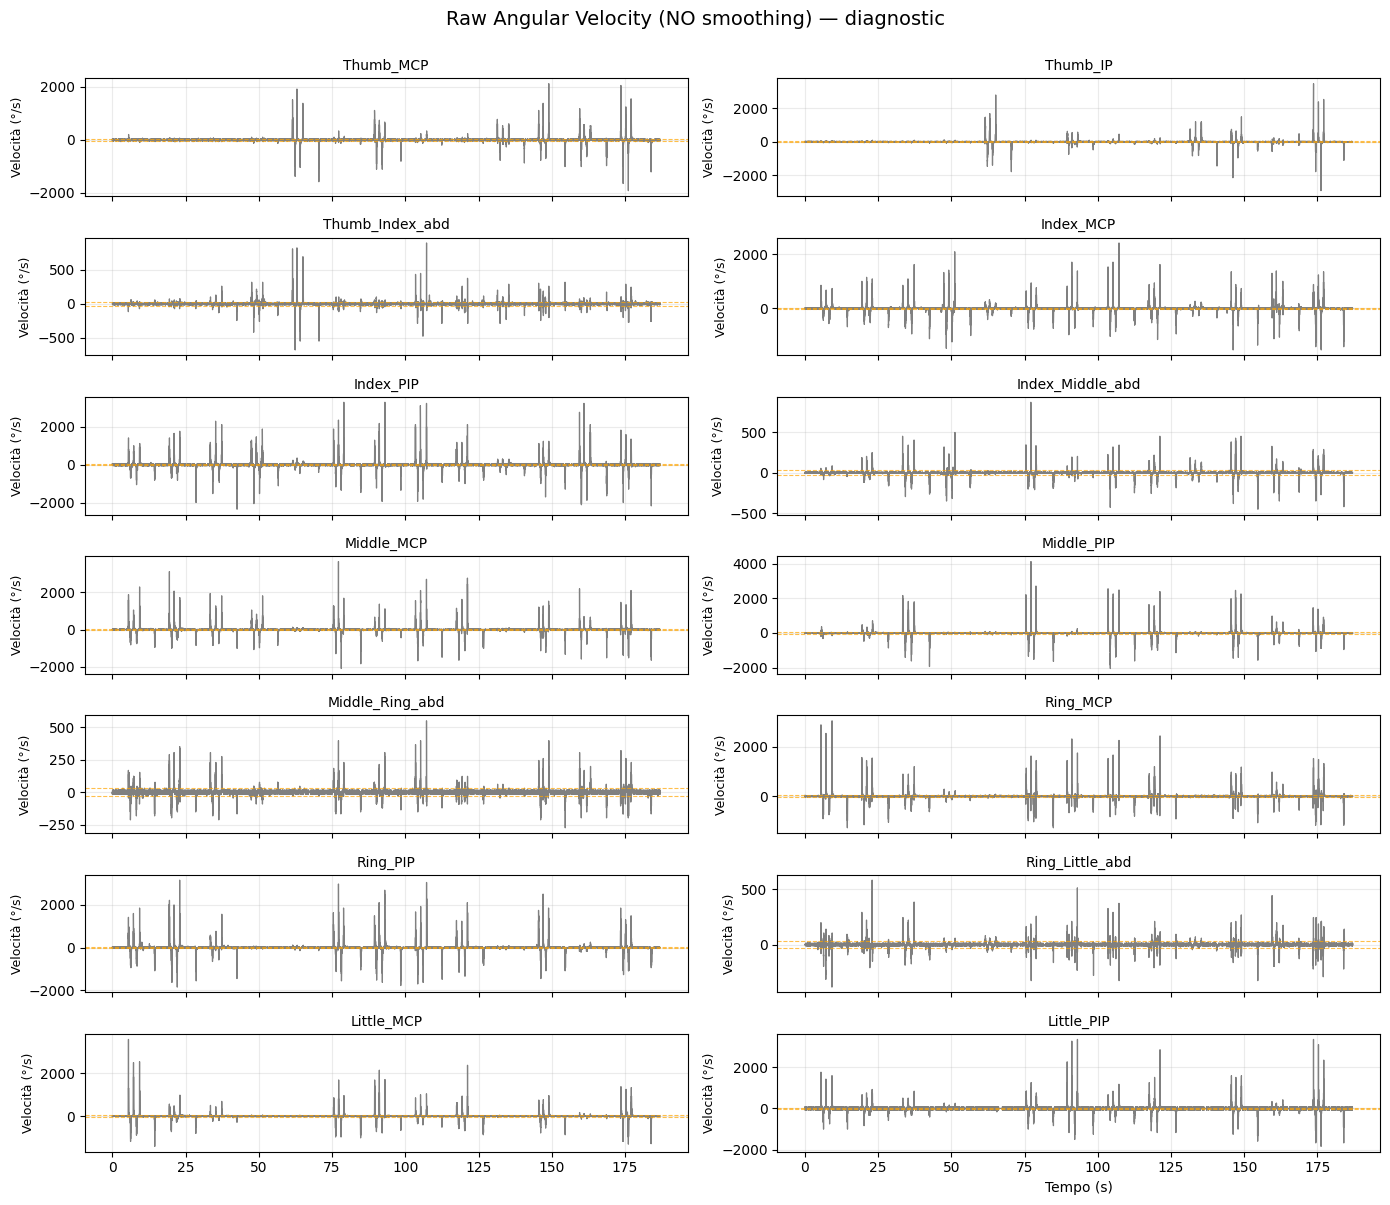

Per-channel peak absolute raw velocities (deg/s):
  Thumb_MCP         :  2123.60
  Thumb_IP          :  3454.27
  Thumb_Index_abd   :   896.39
  Index_MCP         :  2421.26
  Index_PIP         :  3283.95
  Index_Middle_abd  :   868.22
  Middle_MCP        :  3662.42
  Middle_PIP        :  4123.01
  Middle_Ring_abd   :   549.62
  Ring_MCP          :  3044.65
  Ring_PIP          :  3146.47
  Ring_Little_abd   :   580.05
  Little_MCP        :  3573.41
  Little_PIP        :  3333.33


In [42]:
# RAW ANGULAR VELOCITIES 
dt = 1.0 / fs
angles = unity_df[channel_names].values
raw_ang_vel = np.diff(angles, axis=0) / dt
time_vel = np.arange(raw_ang_vel.shape[0]) / fs

# Plot all channels
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
for ch in range(len(channel_names)):
    axes[ch].plot(time_vel, raw_ang_vel[:, ch], color='gray', linewidth=0.9)
    axes[ch].axhline(30.0, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[ch].axhline(-30.0, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[ch].set_title(channel_names[ch], fontsize=10)
    axes[ch].set_ylabel('Velocità (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.25)
axes[-1].set_xlabel('Tempo (s)', fontsize=10)
plt.suptitle('Raw Angular Velocity (NO smoothing) — diagnostic', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

print("Per-channel peak absolute raw velocities (deg/s):")
for i, name in enumerate(channel_names):
    print(f"  {name:18s}: {np.max(np.abs(raw_ang_vel[:, i])):8.2f}")

## Identify Isometric movements

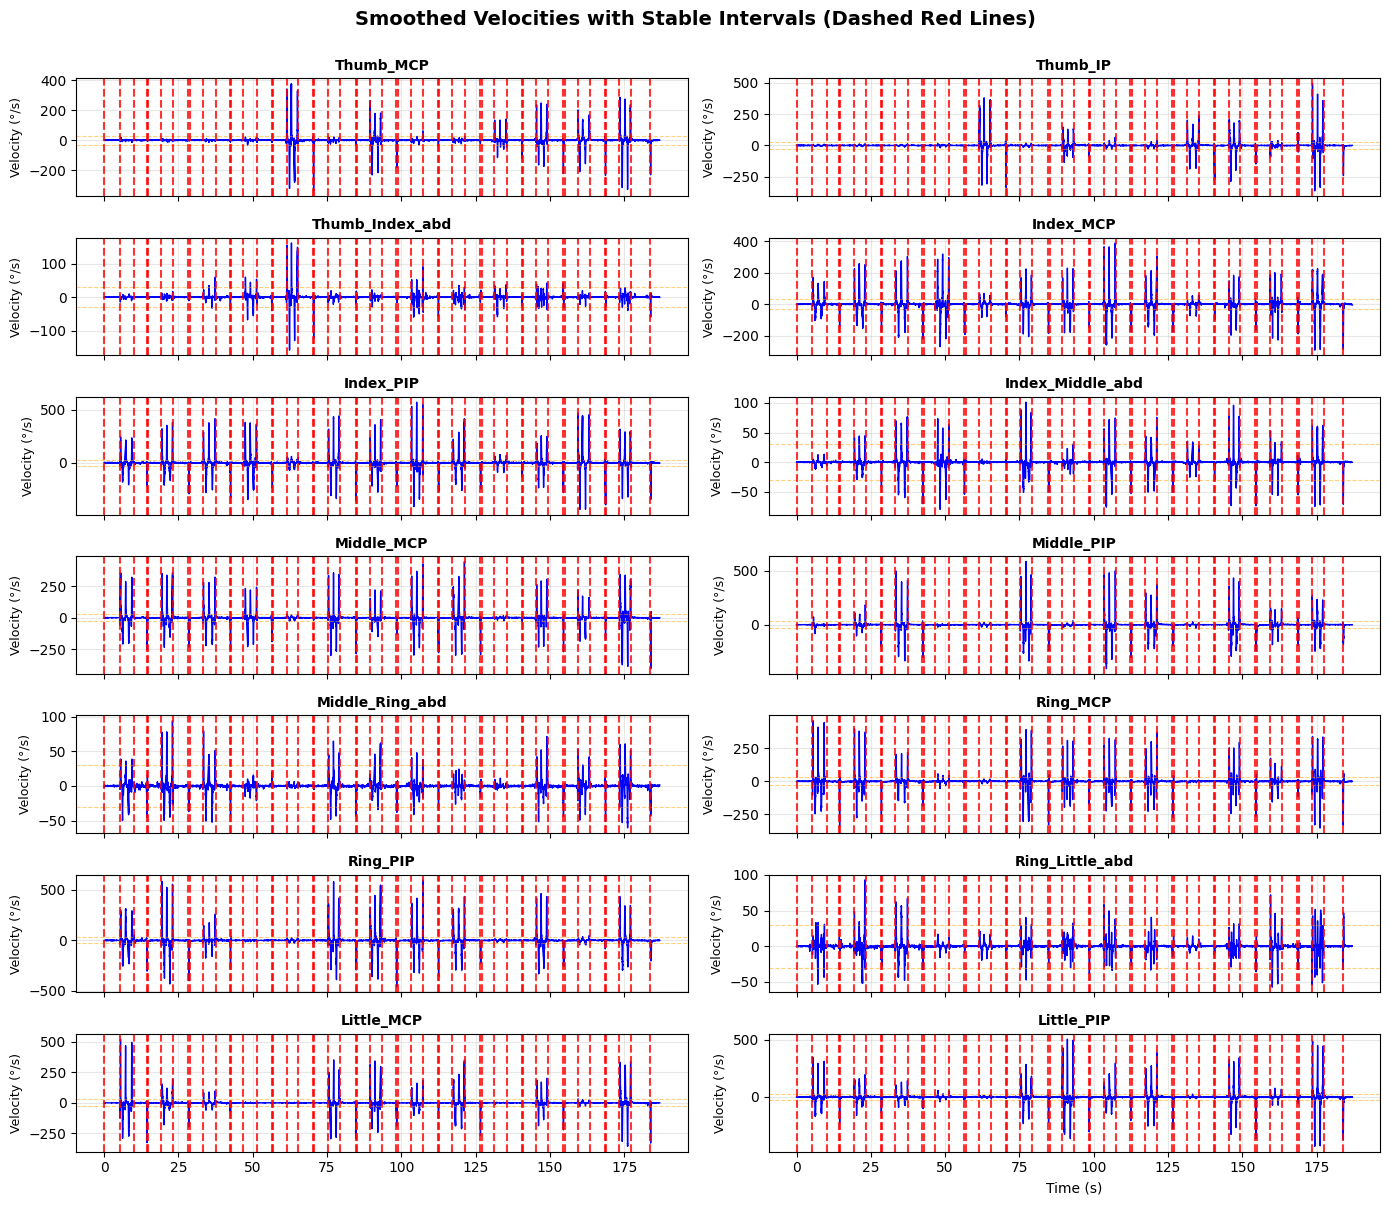


=== ISOMETRIC INTERVALS (velocity < 30.0°/s per ≥ 3.0s on all channels) ===

Periodo 1: 0.00s - 5.37s (duration: 5.37s)
Periodo 2: 10.12s - 14.35s (duration: 4.22s)
Periodo 3: 14.72s - 19.32s (duration: 4.59s)
Periodo 4: 23.27s - 28.39s (duration: 5.12s)
Periodo 5: 28.83s - 33.27s (duration: 4.44s)
Periodo 6: 37.56s - 42.39s (duration: 4.83s)
Periodo 7: 42.82s - 46.59s (duration: 3.77s)
Periodo 8: 51.42s - 56.39s (duration: 4.97s)
Periodo 9: 56.88s - 61.41s (duration: 4.52s)
Periodo 10: 65.33s - 70.36s (duration: 5.03s)
Periodo 11: 70.69s - 75.30s (duration: 4.61s)
Periodo 12: 79.34s - 84.65s (duration: 5.31s)
Periodo 13: 85.20s - 89.36s (duration: 4.16s)
Periodo 14: 93.41s - 98.30s (duration: 4.89s)
Periodo 15: 98.75s - 103.36s (duration: 4.61s)
Periodo 16: 107.47s - 112.38s (duration: 4.91s)
Periodo 17: 112.84s - 117.17s (duration: 4.33s)
Periodo 18: 121.42s - 126.50s (duration: 5.08s)
Periodo 19: 127.00s - 131.36s (duration: 4.36s)
Periodo 20: 135.52s - 140.55s (duration: 5.03s)
Pe

In [43]:
# === SMOOTHING ===
dt = 1.0 / fs
velocity_threshold = 30.0  # °/s
min_stable_duration = 3.0  # seconds
min_stable_samples = int(min_stable_duration * fs)
polyorder = 3

angles = unity_df[channel_names].values  # shape (n_samples, 14)
n_samples = angles.shape[0]

# Odd window_length and <= n_samples
window_length = 51
if window_length >= n_samples:
    window_length = n_samples - 1 if (n_samples - 1) % 2 == 1 else n_samples - 2
if window_length < 3:
    window_length = 3
if window_length % 2 == 0:
    window_length += 1

# Smooth angles with Savitzky-Golay filter
smooth_angles = np.zeros_like(angles)
for i in range(angles.shape[1]):
    smooth_angles[:, i] = savgol_filter(angles[:, i], window_length, polyorder)

# Smoothed velocity in °/s
smooth_velocities = np.diff(smooth_angles, axis=0) / dt
time_vel = np.arange(smooth_velocities.shape[0]) / fs

# Identify stable samples (all channels with |v| < threshold)
is_stable_per_channel = np.abs(smooth_velocities) < velocity_threshold
is_stable_all = np.all(is_stable_per_channel, axis=1)

stable_periods = []
start_idx = None
for i, val in enumerate(is_stable_all):
    if val:
        if start_idx is None:
            start_idx = i
    else:
        if start_idx is not None and (i - start_idx) >= min_stable_samples:
            stable_periods.append((start_idx, i))
        start_idx = None
# Last check at the end of the loop
if start_idx is not None and (len(is_stable_all) - start_idx) >= min_stable_samples:
    stable_periods.append((start_idx, len(is_stable_all)))

# Plot: velocity and red dashed vertical lines at the start/end of stable intervals

fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for ch in range(len(channel_names)):
    axes[ch].plot(time_vel, smooth_velocities[:, ch], linewidth=1, color='blue')
    axes[ch].axhline(y=velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ch].axhline(y=-velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    for start_idx, end_idx in stable_periods:
        axes[ch].axvline(x=time_vel[start_idx], color='red', linestyle='--', linewidth=1.5, alpha=0.8)
        axes[ch].axvline(x=time_vel[end_idx-1], color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    axes[ch].set_title(channel_names[ch], fontsize=10, fontweight='bold')
    axes[ch].set_ylabel('Velocity (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.suptitle('Smoothed Velocities with Stable Intervals (Dashed Red Lines)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


print(f"\n=== ISOMETRIC INTERVALS (velocity < {velocity_threshold}°/s per ≥ {min_stable_duration}s on all channels) ===\n")
if stable_periods:
    for i, (start_idx, end_idx) in enumerate(stable_periods):
        start_time = time_vel[start_idx]
        end_time = time_vel[end_idx-1]
        duration = end_time - start_time
        print(f"Periodo {i+1}: {start_time:.2f}s - {end_time:.2f}s (duration: {duration:.2f}s)")
else:
    print("No stable period found with the current criteria.")

print("\nParameters:")
print(f"  - Velocity threshold: {velocity_threshold}°/s")
print(f"  - Minimum duration: {min_stable_duration}s")
print(f"  - Smoothing: window {window_length} samples, polynomial order {polyorder}")

C:\Users\Charlie XD\AppData\Local\Temp\ipykernel_8660\3030944498.py:39: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


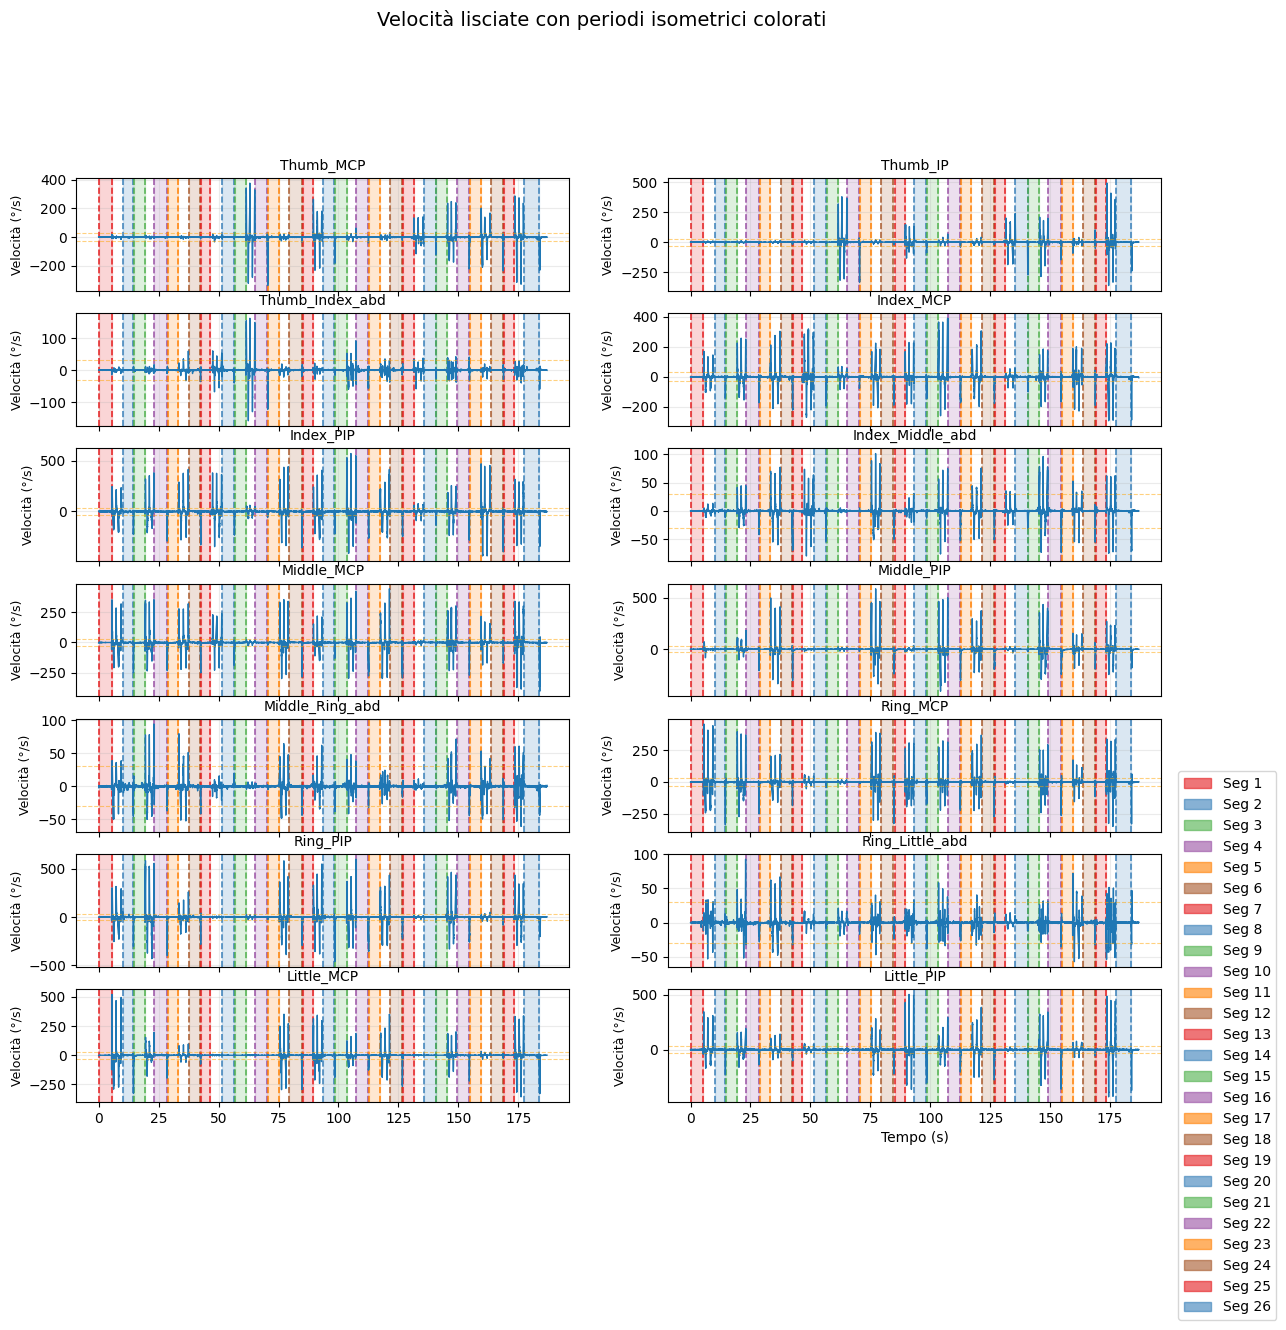

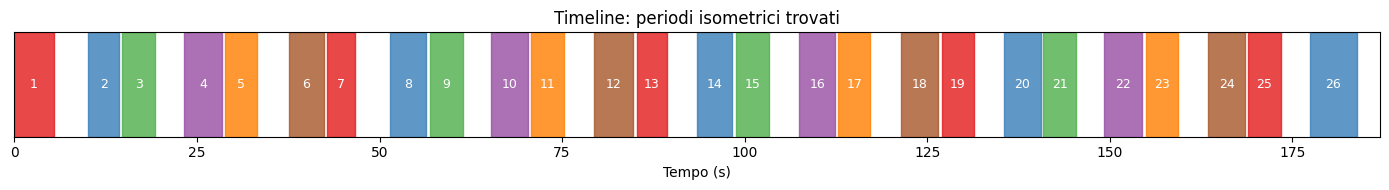

In [44]:
try:
    fs = fs
except NameError:
    fs = 200
dt = 1.0 / fs
colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]  # palette
alpha_shade = 0.18
alpha_lines = 0.9

if 'smooth_velocities' not in globals() or 'time_vel' not in globals() or 'stable_periods' not in globals():
    raise RuntimeError("Compute first `smooth_velocities`, `time_vel` e `stable_periods`.")

# 1) Plot: channel-wise with colored areas (axvspan) and dashed lines at the borders
fig, axes = plt.subplots(7, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()
color_cycle = cycle(colors)
for idx, (start_idx, end_idx) in enumerate(stable_periods):
    c = colors[idx % len(colors)]
    start_t = time_vel[start_idx]
    end_t = time_vel[end_idx - 1]
    for ch in range(len(channel_names)):
        axes[ch].axvspan(start_t, end_t, color=c, alpha=alpha_shade)
        axes[ch].axvline(x=start_t, color=c, linestyle='--', linewidth=1.2, alpha=alpha_lines)
        axes[ch].axvline(x=end_t, color=c, linestyle='--', linewidth=1.2, alpha=alpha_lines)

for ch in range(len(channel_names)):
    axes[ch].plot(time_vel, smooth_velocities[:, ch], color='tab:blue', linewidth=1)
    axes[ch].axhline(y=velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ch].axhline(y=-velocity_threshold, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[ch].set_title(channel_names[ch], fontsize=10)
    axes[ch].set_ylabel('Velocità (°/s)', fontsize=9)
    axes[ch].grid(True, alpha=0.25)

axes[-1].set_xlabel('Tempo (s)', fontsize=10)
plt.suptitle('Velocità lisciate con periodi isometrici colorati', fontsize=14, y=1.02)
# Legend for segments
legend_handles = [mpatches.Patch(color=colors[i % len(colors)], alpha=0.6, label=f"Seg {i+1}") for i in range(len(stable_periods))]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
plt.show()

# 2) Plot: segment division G
fig, ax = plt.subplots(figsize=(14, 2))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Tempo (s)')
ax.set_title('Timeline: periodi isometrici trovati')

for i, (start_idx, end_idx) in enumerate(stable_periods):
    start_t = time_vel[start_idx]
    end_t = time_vel[end_idx - 1]
    ax.axvspan(start_t, end_t, color=colors[i % len(colors)], alpha=0.8)
    ax.text((start_t + end_t) / 2, 0.5, f"{i+1}", ha='center', va='center', color='white', fontsize=9)

# full timeline limits (use time_vel or unity_df time)
t0 = 0.0
tmax = (unity_df.shape[0] - 1) / fs
ax.set_xlim(t0, tmax)
plt.tight_layout()
plt.show()


27 zone di cui 14 di rest e 13 di movimento. 
rest 1 movimento isometria 2, rest 3 movimento isometria 4, rest 5 viola movimento isometria 6 arancio, rest 7 marrone movimento isometria 8 rosso, rest 9 movimento 10, rest 11 movimento 12, rest 13 movimento 14, rest 15 movimento 16, rest 17 movimento 18, rest 19 moviemnto 20, rest 21 movimento 22, rest 23 movimento 24, rest 25 movimento 26, rest 27

In [ ]:
# --- EMG record ---
emg_dir = Path(r"c:\Users\Charlie XD\Documents\AAAUNIVERSITAAAAAAAAAAAA'\Tesi\Motoneuron_Synergies_Driven_Gesture_Prediction\emg_sample_subj_01_trial_01")
emg_record_base = emg_dir / "hdkw_kin_exp03_subj01_1_emg"

rec_emg = wfdb.rdrecord(str(emg_record_base))
emg = rec_emg.p_signal
fs_emg = rec_emg.fs

print("EMG shape:", emg.shape)
print("EMG fs:", fs_emg)

# Use only the movement periods: 2, 4, 6, ...
movement_periods = [
    (zone_idx, start_idx, end_idx)
    for zone_idx, (start_idx, end_idx) in enumerate(stable_periods, start=1)
    if zone_idx % 2 == 0
]

print("Isometric Movement Periods:", len(movement_periods))

emg_segments = []
for zone_idx, start_idx, end_idx in movement_periods:
    t_start = time_vel[start_idx]
    t_end = time_vel[end_idx - 1]

    emg_start = int(round(t_start * fs_emg))
    emg_end = int(round(t_end * fs_emg))

    emg_start = max(0, emg_start)
    emg_end = min(emg.shape[0], emg_end)

    segment = emg[emg_start:emg_end, :]
    emg_segments.append({
        "zone": zone_idx,
        "t_start_s": t_start,
        "t_end_s": t_end,
        "emg_start": emg_start,
        "emg_end": emg_end,
        "samples": segment.shape[0],
        "data": segment
    })

    print(f"Zona {zone_idx}: {t_start:.2f}s - {t_end:.2f}s -> EMG [{emg_start}:{emg_end}] ({segment.shape[0]} campioni)")

for item in emg_segments:
    segment_df = pd.DataFrame(item["data"])
    out_path = emg_dir / f"emg_zone_{item['zone']:02d}.csv"
    segment_df.to_csv(out_path, index=False)

EMG shape: (374000, 448)
EMG fs: 2000
Zone tenute (pari): 13
Zona 2: 9.60s - 14.38s -> EMG [19190:28770] (9580 campioni)
Zona 4: 23.43s - 26.93s -> EMG [46870:53870] (7000 campioni)
Zona 6: 37.65s - 42.44s -> EMG [75290:84880] (9590 campioni)
Zona 8: 51.50s - 56.52s -> EMG [103000:113030] (10030 campioni)
Zona 10: 65.61s - 70.62s -> EMG [131230:141250] (10020 campioni)
Zona 12: 79.44s - 84.37s -> EMG [158890:168740] (9850 campioni)
Zona 14: 93.67s - 98.31s -> EMG [187330:196630] (9300 campioni)
Zona 16: 107.31s - 111.42s -> EMG [214610:222850] (8240 campioni)
Zona 18: 121.67s - 126.39s -> EMG [243350:252790] (9440 campioni)
Zona 20: 135.63s - 140.53s -> EMG [271260:281060] (9800 campioni)
Zona 22: 149.40s - 154.33s -> EMG [298800:308660] (9860 campioni)
Zona 24: 163.68s - 168.30s -> EMG [327360:336600] (9240 campioni)
Zona 26: 177.34s - 182.41s -> EMG [354670:364810] (10140 campioni)


## ITERATE ON TRIALS SUBJECT01

In [46]:
subject01_dir = Path(r"C:\Users\Charlie XD\Documents\emg2mu\hdkw_kin-main\data\subject_01")
segment_mapping = {
    1: [20, 26],
    2: [20, 26],
    3: [20, 25],  # ← Different
    4: [18, 24],  # ← Different
    5: [20, 26],
    6: [20, 26]
}
all_segments = []
rows_meta = []

for trial in range(1, 7):
    print(f"\n--- Trial {trial} ---")
    target_periods_1based = segment_mapping[trial] 
    glove_base = subject01_dir / f"hdkw_kin_exp03_subj01_{trial}_glove"
    emg_base = subject01_dir / f"hdkw_kin_exp03_subj01_{trial}_emg"

    # Load glove
    rec_glove = wfdb.rdrecord(str(glove_base))
    glove_data = rec_glove.p_signal
    fs_glove = 200

    # Mapping raw -> norm -> unity deg (riuso logica già usata nel trial 1)
    raw_df_t = pd.DataFrame(glove_data, columns=channel_names)
    mins_t = raw_df_t[channel_names].min(axis=0)
    maxs_t = raw_df_t[channel_names].max(axis=0)
    ranges_t = (maxs_t - mins_t).replace(0, 1.0)

    norm_df_t = raw_df_t.copy()
    norm_df_t[channel_names] = (raw_df_t[channel_names] - mins_t) / ranges_t
    norm_df_t[channel_names] = norm_df_t[channel_names].clip(0.0, 1.0)

    unity_df_t = pd.DataFrame()
    for ch in channel_names:
        vals = norm_df_t[ch].values
        if ch in flexion_channels:
            deg = vals * flexion_channels[ch]
        elif ch in abduction_channels:
            deg = (vals - 0.5) * abduction_channels[ch]
        else:
            deg = vals * 90.0
        unity_df_t[ch] = sign_map[ch] * deg

    # Smooth + velocity + stable periods (stessi parametri)
    dt_t = 1.0 / fs_glove
    angles_t = unity_df_t[channel_names].values
    n_samples_t = angles_t.shape[0]

    wl_t = 51
    if wl_t >= n_samples_t:
        wl_t = n_samples_t - 1 if (n_samples_t - 1) % 2 == 1 else n_samples_t - 2
    if wl_t < 3:
        wl_t = 3
    if wl_t % 2 == 0:
        wl_t += 1

    smooth_angles_t = np.zeros_like(angles_t)
    for i in range(angles_t.shape[1]):
        smooth_angles_t[:, i] = savgol_filter(angles_t[:, i], wl_t, polyorder)

    smooth_vel_t = np.diff(smooth_angles_t, axis=0) / dt_t
    time_vel_t = np.arange(smooth_vel_t.shape[0]) / fs_glove

    min_stable_samples_t = int(min_stable_duration * fs_glove)
    is_stable_all_t = np.all(np.abs(smooth_vel_t) < velocity_threshold, axis=1)

    stable_periods_t = []
    start_idx = None
    for i, val in enumerate(is_stable_all_t):
        if val and start_idx is None:
            start_idx = i
        elif (not val) and start_idx is not None:
            if (i - start_idx) >= min_stable_samples_t:
                stable_periods_t.append((start_idx, i))
            start_idx = None
    if start_idx is not None and (len(is_stable_all_t) - start_idx) >= min_stable_samples_t:
        stable_periods_t.append((start_idx, len(is_stable_all_t)))

    expected_segments = 27
    n_found = len(stable_periods_t)

    print(f"Found Periods: {n_found}")


    # Load EMG
    rec_emg_t = wfdb.rdrecord(str(emg_base))
    emg_t = rec_emg_t.p_signal
    fs_emg_t = rec_emg_t.fs

    # Only segment 20 and 26
    for seg_id in target_periods_1based:
        if seg_id <= len(stable_periods_t):
            s_idx, e_idx = stable_periods_t[seg_id - 1]
            t_start = time_vel_t[s_idx]
            t_end = time_vel_t[e_idx - 1]

            emg_start = int(round(t_start * fs_emg_t))
            emg_end = int(round(t_end * fs_emg_t))
            emg_start = max(0, emg_start)
            emg_end = min(emg_t.shape[0], emg_end)

            seg = emg_t[emg_start:emg_end, :]
            all_segments.append(seg)

            rows_meta.append({
                "trial": trial,
                "segment_id": seg_id,
                "t_start_s": t_start,
                "t_end_s": t_end,
                "emg_start": emg_start,
                "emg_end": emg_end,
                "samples": seg.shape[0]
            })

            print(f"  Segmento {seg_id}: {seg.shape[0]} samples")
        else:
            print(f"  Segmento {seg_id}: NON TROVATO")

# Concatenation
if len(all_segments) == 0:
    raise RuntimeError("Nessun segmento estratto (20/26) nei trial processati.")

emg_concat = np.vstack(all_segments)
print("\n=== SEGNALE CONCATENATO FINALE ===")
print("Shape:", emg_concat.shape)

# Save
out_dir = subject01_dir / "filtered_movement_only"
out_dir.mkdir(parents=True, exist_ok=True)

out_csv = out_dir / "subject01_trials1to6_segments20_26_concatenated.csv"
meta_csv = out_dir / "subject01_trials1to6_segments20_26_metadata.csv"

pd.DataFrame(emg_concat).to_csv(out_csv, index=False)
pd.DataFrame(rows_meta).to_csv(meta_csv, index=False)

print("Saved:", out_csv)
print("Saved:", meta_csv)


--- Trial 1 ---
Found Periods: 27
  Segmento 20: 9800 samples
  Segmento 26: 10140 samples

--- Trial 2 ---
Found Periods: 27
  Segmento 20: 10460 samples
  Segmento 26: 9640 samples

--- Trial 3 ---
Found Periods: 26
  Segmento 20: 10120 samples
  Segmento 25: 9730 samples

--- Trial 4 ---
Found Periods: 25
  Segmento 18: 9440 samples
  Segmento 24: 10160 samples

--- Trial 5 ---
Found Periods: 27
  Segmento 20: 9700 samples
  Segmento 26: 10100 samples

--- Trial 6 ---
Found Periods: 26
  Segmento 20: 10060 samples
  Segmento 26: 12790 samples

=== SEGNALE CONCATENATO FINALE ===
Shape: (122140, 448)
Saved: C:\Users\Charlie XD\Documents\emg2mu\hdkw_kin-main\data\subject_01\filtered_movement_only\subject01_trials1to6_segments20_26_concatenated.csv
Saved: C:\Users\Charlie XD\Documents\emg2mu\hdkw_kin-main\data\subject_01\filtered_movement_only\subject01_trials1to6_segments20_26_metadata.csv
